In [1]:
# ============================================================
# PIPELINE COMPLETO TFM (VERSIÓN FINAL CON LOGGING)
# ============================================================


# ============================================================
# A: PREPARACIÓN
# ============================================================

# ------------------------------------------------------------
# A1. Configuración e imports
# ------------------------------------------------------------

import numpy as np
import pandas as pd
import GEOparse
import matplotlib.pyplot as plt
import time

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, RFE
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import roc_auc_score, roc_curve

print("\n=== CONFIGURACIÓN ===")

RANDOM_STATE = 42
K_VALUES = [20, 50, 100, 500, 1000]


# ------------------------------------------------------------
# A2. Carga dataset GSE55348
# ------------------------------------------------------------

print("\n=== CARGANDO GSE55348 ===")

gse = GEOparse.get_GEO("GSE55348", destdir="../data")

expr_data = {}

for gsm_name, gsm in gse.gsms.items():
    expr_data[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

X = pd.DataFrame(expr_data).T

print("Shape X:", X.shape)


# ------------------------------------------------------------
# A3. Labels
# ------------------------------------------------------------

print("\n=== EXTRACCIÓN DE LABELS ===")

y = []

for gsm_name, gsm in gse.gsms.items():
    chars = gsm.metadata.get("characteristics_ch1", [])
    label = None

    for c in chars:
        c = c.lower()
        if "event:" in c:
            label = int(c.split(":")[-1].strip())

    if label is None:
        raise ValueError(f"No label en {gsm_name}")

    y.append(label)

y = np.array(y)

print("Distribución clases:", np.bincount(y))


# ------------------------------------------------------------
# A4. Log transform
# ------------------------------------------------------------

print("\n=== LOG TRANSFORM ===")

X_log = np.log2(X + 1)



07-Apr-2026 19:13:11 INFO GEOparse - Downloading ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE55nnn/GSE55348/soft/GSE55348_family.soft.gz to ../data\GSE55348_family.soft.gz



=== CONFIGURACIÓN ===

=== CARGANDO GSE55348 ===


100%|█████████████████████████████████████████████████████████████████████████████| 25.1M/25.1M [00:02<00:00, 9.36MB/s]
07-Apr-2026 19:13:15 DEBUG downloader - Size validation passed
07-Apr-2026 19:13:15 DEBUG downloader - Moving C:\Users\peter\AppData\Local\Temp\tmphm3d868r to C:\Users\peter\Desktop\TFM\data\GSE55348_family.soft.gz
07-Apr-2026 19:13:15 DEBUG downloader - Successfully downloaded ftp://ftp.ncbi.nlm.nih.gov/geo/series/GSE55nnn/GSE55348/soft/GSE55348_family.soft.gz
07-Apr-2026 19:13:15 INFO GEOparse - Parsing ../data\GSE55348_family.soft.gz: 
07-Apr-2026 19:13:15 DEBUG GEOparse - DATABASE: GeoMiame
07-Apr-2026 19:13:15 DEBUG GEOparse - SERIES: GSE55348
07-Apr-2026 19:13:15 DEBUG GEOparse - PLATFORM: GPL14951
07-Apr-2026 19:13:16 DEBUG GEOparse - SAMPLE: GSM1334487
07-Apr-2026 19:13:16 DEBUG GEOparse - SAMPLE: GSM1334488
07-Apr-2026 19:13:16 DEBUG GEOparse - SAMPLE: GSM1334489
07-Apr-2026 19:13:16 DEBUG GEOparse - SAMPLE: GSM1334490
07-Apr-2026 19:13:16 DEBUG GEOparse - SA

Shape X: (53, 29377)

=== EXTRACCIÓN DE LABELS ===
Distribución clases: [30 23]

=== LOG TRANSFORM ===


In [2]:
# ============================================================
# B: EXPERIMENTACIÓN COMPLETA (MÉTRICAS + CONFUSIÓN)
# ============================================================

from sklearn.model_selection import cross_validate, cross_val_predict
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    matthews_corrcoef
)

print("\n=== EXPERIMENTO K ===")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_results = []

for K in K_VALUES:

    print(f"\nEvaluando K = {K}")

    pipelines = {

        # ------------------------------------------------------------
        # BASELINE
        # ------------------------------------------------------------
        "LR baseline": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000))
        ]),

        # ------------------------------------------------------------
        # ANOVA
        # ------------------------------------------------------------
        "LR + ANOVA": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(f_classif, k=K)),
            ("model", LogisticRegression(max_iter=1000))
        ]),

        # ------------------------------------------------------------
        # MUTUAL INFORMATION
        # ------------------------------------------------------------
        "LR + MutualInfo": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("select", SelectKBest(lambda X, y: mutual_info_classif(X, y), k=K)),
            ("model", LogisticRegression(max_iter=1000))
        ]),

        # ------------------------------------------------------------
        # RFE
        # ------------------------------------------------------------
        "LR + RFE": Pipeline([
            ("variance", VarianceThreshold(0.01)),
            ("scaler", StandardScaler()),
            ("select", RFE(LogisticRegression(max_iter=1000), n_features_to_select=K, step=50)),
            ("model", LogisticRegression(max_iter=1000))
        ])
    }

    for name, pipe in pipelines.items():

        print(f"Modelo: {name}")
        start = time.time()

        # ------------------------------------------------------------
        # CV CLÁSICO (AUC, F1, ACC)
        # ------------------------------------------------------------
        scores = cross_validate(
            pipe,
            X_log,
            y,
            cv=cv,
            scoring={
                "roc_auc": "roc_auc",
                "f1": "f1",
                "accuracy": "accuracy"
            },
            n_jobs=2
        )

        # ------------------------------------------------------------
        # PREDICCIONES OUT-OF-FOLD (CLAVE)
        # ------------------------------------------------------------
        y_pred = cross_val_predict(pipe, X_log, y, cv=cv, n_jobs=2)
        y_prob = cross_val_predict(pipe, X_log, y, cv=cv, method="predict_proba", n_jobs=2)[:, 1]

        # ------------------------------------------------------------
        # MATRIZ DE CONFUSIÓN GLOBAL
        # ------------------------------------------------------------
        tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

        # ------------------------------------------------------------
        # MÉTRICAS CLÍNICAS
        # ------------------------------------------------------------
        sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall positivo
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        precision = precision_score(y, y_pred)
        recall = recall_score(y, y_pred)

        balanced_acc = balanced_accuracy_score(y, y_pred)
        mcc = matthews_corrcoef(y, y_pred)

        end = time.time()
        print(f"Tiempo: {end - start:.2f} s")

        # ------------------------------------------------------------
        # GUARDADO DE RESULTADOS
        # ------------------------------------------------------------
        all_results.append({
            "Model": name,
            "K": K,

            # Métricas CV estándar
            "ROC-AUC": np.mean(scores["test_roc_auc"]),
            "F1": np.mean(scores["test_f1"]),
            "Accuracy": np.mean(scores["test_accuracy"]),

            # Métricas clínicas
            "Sensitivity": sensitivity,
            "Specificity": specificity,
            "Precision": precision,
            "Balanced Acc": balanced_acc,
            "MCC": mcc,

            # Confusion matrix
            "TP": tp,
            "TN": tn,
            "FP": fp,
            "FN": fn
        })


# ============================================================
# B2: L1 (REGULARIZACIÓN)
# ============================================================

print("\n=== EXPERIMENTO L1 ===")

C_VALUES = [0.01, 0.1, 1]
l1_results = []

for C in C_VALUES:

    print(f"Evaluando C = {C}")

    pipe = Pipeline([
        ("variance", VarianceThreshold(0.01)),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            penalty="l1",
            solver="saga",
            C=C,
            max_iter=5000
        ))
    ])

    # ------------------------------------------------------------
    # CV estándar
    # ------------------------------------------------------------
    scores = cross_validate(
        pipe,
        X_log,
        y,
        cv=cv,
        scoring={
            "roc_auc": "roc_auc",
            "f1": "f1",
            "accuracy": "accuracy"
        },
        n_jobs=2
    )

    # ------------------------------------------------------------
    # PREDICCIONES OOF
    # ------------------------------------------------------------
    y_pred = cross_val_predict(pipe, X_log, y, cv=cv, n_jobs=2)

    tn, fp, fn, tp = confusion_matrix(y, y_pred).ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    precision = precision_score(y, y_pred)

    balanced_acc = balanced_accuracy_score(y, y_pred)
    mcc = matthews_corrcoef(y, y_pred)

    l1_results.append({
        "Model": "LR L1",
        "C": C,

        "ROC-AUC": np.mean(scores["test_roc_auc"]),
        "F1": np.mean(scores["test_f1"]),
        "Accuracy": np.mean(scores["test_accuracy"]),

        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "Precision": precision,
        "Balanced Acc": balanced_acc,
        "MCC": mcc,

        "TP": tp,
        "TN": tn,
        "FP": fp,
        "FN": fn
    })


=== EXPERIMENTO K ===

Evaluando K = 20
Modelo: LR baseline
Tiempo: 8.57 s
Modelo: LR + ANOVA
Tiempo: 5.64 s
Modelo: LR + MutualInfo
Tiempo: 389.32 s
Modelo: LR + RFE
Tiempo: 366.89 s

Evaluando K = 50
Modelo: LR baseline
Tiempo: 6.95 s
Modelo: LR + ANOVA
Tiempo: 5.16 s
Modelo: LR + MutualInfo
Tiempo: 368.32 s
Modelo: LR + RFE
Tiempo: 349.66 s

Evaluando K = 100
Modelo: LR baseline
Tiempo: 6.74 s
Modelo: LR + ANOVA
Tiempo: 5.80 s
Modelo: LR + MutualInfo
Tiempo: 374.60 s
Modelo: LR + RFE
Tiempo: 358.44 s

Evaluando K = 500
Modelo: LR baseline
Tiempo: 6.59 s
Modelo: LR + ANOVA
Tiempo: 5.54 s
Modelo: LR + MutualInfo
Tiempo: 365.11 s
Modelo: LR + RFE
Tiempo: 347.58 s

Evaluando K = 1000
Modelo: LR baseline
Tiempo: 7.06 s
Modelo: LR + ANOVA
Tiempo: 5.04 s
Modelo: LR + MutualInfo
Tiempo: 358.01 s
Modelo: LR + RFE
Tiempo: 357.52 s

=== EXPERIMENTO L1 ===
Evaluando C = 0.01
Evaluando C = 0.1
Evaluando C = 1


In [13]:
# ============================================================
# C: ENTRENAMIENTO FINAL Y SELECCIÓN DE GENES (ANOVA)
# ============================================================

# ------------------------------------------------------------
# C1. Entrenamiento modelo final (LR + ANOVA)
# Entrenamos en TODO el dataset para obtener biomarcadores
# ------------------------------------------------------------

print("\n=== ENTRENAMIENTO MODELO FINAL (ANOVA) ===")

# IMPORTANTE:
# Usamos ANOVA porque ha mostrado mejor sensibilidad en CV,
# lo cual es crítico en un problema clínico (minimizar falsos negativos)

final_pipe = Pipeline([
    ("variance", VarianceThreshold(0.01)),     # Eliminamos genes con baja varianza
    ("scaler", StandardScaler()),              # Normalización
    ("select", SelectKBest(f_classif, k=20)),  # Selección ANOVA (K=20)
    ("model", LogisticRegression(max_iter=1000))
])

# Entrenamos con TODOS los datos
final_pipe.fit(X_log, y)


# ------------------------------------------------------------
# C2. Selección de genes
# ------------------------------------------------------------

# A diferencia de L1:
# - Aquí NO usamos coeficientes
# - Usamos directamente el selector ANOVA
# 1. Genes tras filtro de varianza
mask_var = final_pipe.named_steps["variance"].get_support()
genes_after_variance = X_log.columns[mask_var]

# 2. Selección ANOVA sobre esos genes
mask_select = final_pipe.named_steps["select"].get_support()
selected_genes = genes_after_variance[mask_select]

print("Número de genes seleccionados (probes):", len(selected_genes))
print(selected_genes)


# ------------------------------------------------------------
# C3. MAPPING A GENES REALES
# Convertimos probes → símbolos génicos
# ------------------------------------------------------------

print("\n=== MAPEO A GENES (GSE55348) ===")

# Cargamos anotación de la plataforma
platform_55348 = gse.gpls[list(gse.gpls.keys())[0]]
annot_55348 = platform_55348.table

# Diccionario probe → símbolo génico
map_55348 = dict(zip(annot_55348['ID'], annot_55348['Symbol']))

# Aplicamos mapping
mapped_selected_genes = [map_55348.get(g) for g in selected_genes]

# Limpieza:
# - eliminamos None
# - eliminamos duplicados manteniendo orden
mapped_selected_genes = list(dict.fromkeys(
    [g for g in mapped_selected_genes if g is not None]
))

print("Número de genes mapeados (únicos):", len(mapped_selected_genes))
print(mapped_selected_genes)


=== ENTRENAMIENTO MODELO FINAL (ANOVA) ===
Número de genes seleccionados (probes): 20
Index(['ILMN_1727078', 'ILMN_1690209', 'ILMN_1662935', 'ILMN_1720833',
       'ILMN_1651415', 'ILMN_1728761', 'ILMN_1717902', 'ILMN_2352131',
       'ILMN_1651642', 'ILMN_1740762', 'ILMN_1798582', 'ILMN_2405254',
       'ILMN_1806721', 'ILMN_1662174', 'ILMN_1805636', 'ILMN_1746359',
       'ILMN_1773459', 'ILMN_1804316', 'ILMN_1769219', 'ILMN_1710427'],
      dtype='object', name='ID_REF')

=== MAPEO A GENES (GSE55348) ===
Número de genes mapeados (únicos): 16
['C17orf37', 'C1orf186', 'C1QTNF7', 'C2orf48', 'DERL3', 'ERBB2', 'GPC2', 'GRB7', 'MS4A2', 'ORMDL3', 'PGAP3', 'RERG', 'SOX11', 'TCAP', 'TPSG1', 'VPS37B']


In [19]:
# ============================================================
# D: VALIDACIÓN EXTERNA 
# ============================================================

print("\n=== VALIDACIÓN EXTERNA ===")

# Dataset externo independiente
gse_58984 = GEOparse.get_GEO("GSE58984", destdir="../data")


# ------------------------------------------------------------
# D1. Cargar datos de expresión
# ------------------------------------------------------------

expr_data_58984 = {}

for gsm_name, gsm in gse_58984.gsms.items():
    expr_data_58984[gsm_name] = gsm.table.set_index("ID_REF")["VALUE"]

X_58984 = pd.DataFrame(expr_data_58984).T

# Transformación log2 (igual que en training → MUY IMPORTANTE)
X_58984_log = np.log2(X_58984 + 1)


# ------------------------------------------------------------
# D2. Extracción de labels
# ------------------------------------------------------------

# IMPORTANTE:
# Este dataset usa "distant metastasis" como variable clínica

y_58984 = []

for gsm_name in X_58984.index:
    gsm = gse_58984.gsms[gsm_name]
    chars = gsm.metadata.get("characteristics_ch1", [])

    label = None

    for c in chars:
        c = c.lower()

        if "distant metastasis" in c:
            label = int(c.split(":")[-1].strip())

    # Control de errores → evita labels corruptos
    if label is None:
        raise ValueError(f"No label encontrado en {gsm_name}")

    y_58984.append(label)

y_58984 = np.array(y_58984)

print("Distribución externa:", np.bincount(y_58984))


# ------------------------------------------------------------
# D3. Mapping de probes → genes
# ------------------------------------------------------------

print("\n=== MAPEO A GENES (GSE58984) ===")

platform_58984 = gse_58984.gpls[list(gse_58984.gpls.keys())[0]]
annot_58984 = platform_58984.table

# Diccionario probe → símbolo génico
map_58984 = dict(zip(annot_58984['ID'], annot_58984['Gene Symbol']))

# Aplicar mapping
X_58984_genes = X_58984_log.rename(columns=map_58984)

# Limpieza de nombres (muy importante en GEO)
X_58984_genes.columns = [
    str(g).split("///")[0].strip() if g is not None else None
    for g in X_58984_genes.columns
]

# Eliminar columnas sin nombre válido
X_58984_genes = X_58984_genes.loc[:, X_58984_genes.columns.notna()]

# Agrupar genes duplicados (media)
X_58984_genes = X_58984_genes.T.groupby(level=0).mean().T


# ------------------------------------------------------------
# D4. Limpieza de genes del training
# ------------------------------------------------------------

mapped_selected_genes_clean = [
    g.split("///")[0].strip() if isinstance(g, str) else g
    for g in mapped_selected_genes
]


# ------------------------------------------------------------
# D5. Intersección de genes (CRÍTICO)
# ------------------------------------------------------------

common_genes = [
    g for g in mapped_selected_genes_clean
    if g in X_58984_genes.columns
]

print("Genes comunes:", len(common_genes))
print(common_genes)


# ------------------------------------------------------------
# D6. Control de calidad
# ------------------------------------------------------------

if len(common_genes) < 5:
    print("WARNING: Muy pocos genes comunes → validación poco fiable")


# ------------------------------------------------------------
# D7. Preparar TRAIN (solo genes comunes)
# ------------------------------------------------------------

# 1. Seleccionar probes
X_train = X_log[selected_genes].copy()

# 2. Mapping probe → gene
probe_to_gene = dict(zip(selected_genes, mapped_selected_genes_clean))

# 3. Renombrar columnas
X_train = X_train.rename(columns=probe_to_gene)

# 4. Agrupar genes duplicados
X_train = X_train.T.groupby(level=0).mean().T

# 5. Quedarse con genes comunes
X_train = X_train[common_genes]


# ------------------------------------------------------------
# D8. Preparar TEST (alineado con train)
# ------------------------------------------------------------

X_test = X_58984_genes.copy()

# MISMO ORDEN de genes (clave para el modelo)
X_test = X_test.reindex(columns=common_genes)


# ------------------------------------------------------------
# DEBUG (muy útil para detectar errores)
# ------------------------------------------------------------

print("Train columns:", list(X_train.columns))
print("Test columns:", list(X_test.columns))

print("Shape train:", X_train.shape)
print("Shape test:", X_test.shape)


# ============================================================
# D9. ESCALADO CORRECTO (IMPORTANTE)
# ============================================================

# IMPORTANTE:
# El scaler se ajusta SOLO con el train y luego se aplica al test.
# Esto evita introducir información del test en el modelo (data leakage)
# y asegura que ambas matrices estén en la misma escala.

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ------------------------------------------------------------
# D10. Modelo final
# ------------------------------------------------------------

# IMPORTANTE:
# Usamos class_weight="balanced" porque el dataset externo está desbalanceado.
# Esto penaliza más los errores en la clase minoritaria.

model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model.fit(X_train_scaled, y)


# ------------------------------------------------------------
# D11. Predicción
# ------------------------------------------------------------

y_pred = model.predict_proba(X_test_scaled)[:, 1]


# ------------------------------------------------------------
# D12. Métricas
# ------------------------------------------------------------

from sklearn.metrics import confusion_matrix, roc_curve

# AUC (mide capacidad de ranking, independiente del threshold)
auc = roc_auc_score(y_58984, y_pred)
auc_inv = roc_auc_score(y_58984, 1 - y_pred)


# ------------------------------------------------------------
# Ajuste de threshold (MUY IMPORTANTE)
# ------------------------------------------------------------

# Usamos el índice de Youden para encontrar el mejor equilibrio
# entre sensibilidad y especificidad

fpr, tpr, thresholds = roc_curve(y_58984, y_pred)

best_idx = (tpr - fpr).argmax()
best_threshold = thresholds[best_idx]

print("Threshold óptimo:", best_threshold)

# Clasificación con threshold óptimo
y_pred_class = (y_pred >= best_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(y_58984, y_pred_class).ravel()

sensibilidad = tp / (tp + fn) if (tp + fn) > 0 else 0
especificidad = tn / (tn + fp) if (tn + fp) > 0 else 0
print("\n=== DEBUG PROBABILIDADES ===")
print("Min:", y_pred.min())
print("Max:", y_pred.max())
print("Media:", y_pred.mean())

# ============================================================
# ANÁLISIS DE THRESHOLDS (IMPORTANTE EN CONTEXTO CLÍNICO)
# ============================================================

print("\n=== ANÁLISIS DE THRESHOLDS ===")

thresholds_to_test = [0.2, 0.3, 0.4, 0.5]

for t in thresholds_to_test:

    y_pred_class_t = (y_pred >= t).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_58984, y_pred_class_t).ravel()

    sens = tp / (tp + fn) if (tp + fn) > 0 else 0
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0

    print(f"Threshold {t:.2f} → Sensibilidad: {sens:.3f}, Especificidad: {spec:.3f}")


# ------------------------------------------------------------
# RESULTADOS
# ------------------------------------------------------------

print("\n=== MÉTRICAS EXTERNAS ===")
print("AUC:", auc)
print("AUC invertido:", auc_inv)
print("Sensibilidad:", sensibilidad)
print("Especificidad:", especificidad)

# ============================================================
# INTERPRETACIÓN
# ============================================================
# En problemas médicos (como cáncer), no siempre interesa usar threshold = 0.5.
# Un threshold más bajo puede reducir falsos negativos (FN), es decir,
# pacientes enfermos clasificados como sanos.
# - Threshold bajo (ej: 0.2-0.3):
#   ↑ Sensibilidad (menos falsos negativos)
#   ↓ Especificidad (más falsos positivos)
#
# - Threshold alto (ej: 0.5 o el de Youden):
#   ↓ Sensibilidad
#   ↑ Especificidad
#
# En cáncer suele ser preferible priorizar sensibilidad,
# ya que un falso negativo tiene consecuencias más graves.

07-Apr-2026 23:08:57 DEBUG utils - Directory ../data already exists. Skipping.
07-Apr-2026 23:08:57 INFO GEOparse - File already exist: using local version.
07-Apr-2026 23:08:57 INFO GEOparse - Parsing ../data\GSE58984_family.soft.gz: 
07-Apr-2026 23:08:57 DEBUG GEOparse - DATABASE: GeoMiame
07-Apr-2026 23:08:57 DEBUG GEOparse - SERIES: GSE58984
07-Apr-2026 23:08:57 DEBUG GEOparse - PLATFORM: GPL570



=== VALIDACIÓN EXTERNA ===


C:\ProgramData\anaconda3\Lib\site-packages\GEOparse\GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
07-Apr-2026 23:08:58 DEBUG GEOparse - SAMPLE: GSM1423346
07-Apr-2026 23:08:58 DEBUG GEOparse - SAMPLE: GSM1423347
07-Apr-2026 23:08:58 DEBUG GEOparse - SAMPLE: GSM1423348
07-Apr-2026 23:08:58 DEBUG GEOparse - SAMPLE: GSM1423349
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423350
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423351
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423352
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423353
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423354
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423355
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423356
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423357
07-Apr-2026 23:08:59 DEBUG GEOparse - SAMPLE: GSM1423358
07-Apr-2026 23:08:59 DEBUG GEO

Distribución externa: [83 11]

=== MAPEO A GENES (GSE58984) ===
Genes comunes: 14
['C1orf186', 'C1QTNF7', 'DERL3', 'ERBB2', 'GPC2', 'GRB7', 'MS4A2', 'ORMDL3', 'PGAP3', 'RERG', 'SOX11', 'TCAP', 'TPSG1', 'VPS37B']
Train columns: ['C1orf186', 'C1QTNF7', 'DERL3', 'ERBB2', 'GPC2', 'GRB7', 'MS4A2', 'ORMDL3', 'PGAP3', 'RERG', 'SOX11', 'TCAP', 'TPSG1', 'VPS37B']
Test columns: ['C1orf186', 'C1QTNF7', 'DERL3', 'ERBB2', 'GPC2', 'GRB7', 'MS4A2', 'ORMDL3', 'PGAP3', 'RERG', 'SOX11', 'TCAP', 'TPSG1', 'VPS37B']
Shape train: (53, 14)
Shape test: (94, 14)
Threshold óptimo: 0.9994421169282345

=== DEBUG PROBABILIDADES ===
Min: 0.99896995283056
Max: 0.9996300204293287
Media: 0.9993576019623157

=== ANÁLISIS DE THRESHOLDS ===
Threshold 0.20 → Sensibilidad: 1.000, Especificidad: 0.000
Threshold 0.30 → Sensibilidad: 1.000, Especificidad: 0.000
Threshold 0.40 → Sensibilidad: 1.000, Especificidad: 0.000
Threshold 0.50 → Sensibilidad: 1.000, Especificidad: 0.000

=== MÉTRICAS EXTERNAS ===
AUC: 0.660460021905805


=== CURVA ROC ===


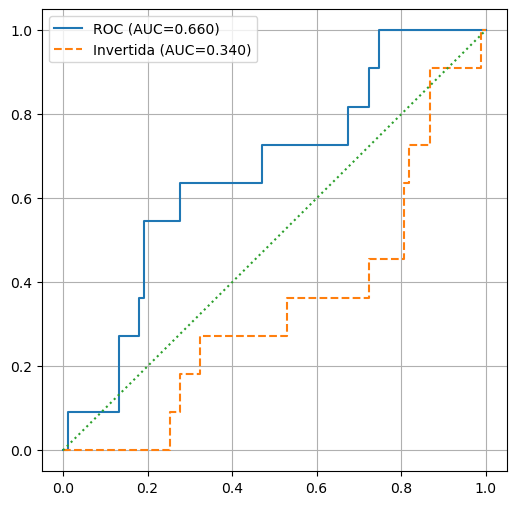


=== FIN PIPELINE ===


In [20]:

# ============================================================
# E: VISUALIZACIÓN
# ============================================================

print("\n=== CURVA ROC ===")

fpr, tpr, _ = roc_curve(y_58984, y_pred)
fpr_inv, tpr_inv, _ = roc_curve(y_58984, 1 - y_pred)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"ROC (AUC={auc:.3f})")
plt.plot(fpr_inv, tpr_inv, linestyle="--", label=f"Invertida (AUC={auc_inv:.3f})")
plt.plot([0,1],[0,1], linestyle=":")
plt.legend()
plt.grid()
plt.show()

print("\n=== FIN PIPELINE ===")

In [21]:
# Métricas adicionales
print("\n=== RESULTADOS EXPERIMENTO K ===")

results_df = pd.DataFrame(all_results)

# Ordenar por AUC
results_df = results_df.sort_values(by="ROC-AUC", ascending=False)

print(results_df)
print("\n=== RESULTADOS L1 ===")

l1_df = pd.DataFrame(l1_results)
l1_df = l1_df.sort_values(by="ROC-AUC", ascending=False)

print(l1_df)


=== RESULTADOS EXPERIMENTO K ===
              Model     K   ROC-AUC        F1  Accuracy  Sensitivity  \
2   LR + MutualInfo    20  0.903333  0.727778  0.754545     0.739130   
1        LR + ANOVA    20  0.896667  0.822222  0.829091     0.826087   
5        LR + ANOVA    50  0.860000  0.733333  0.756364     0.739130   
6   LR + MutualInfo    50  0.848333  0.694488  0.734545     0.695652   
10  LR + MutualInfo   100  0.840000  0.696869  0.734545     0.695652   
9        LR + ANOVA   100  0.831667  0.644444  0.678182     0.652174   
7          LR + RFE    50  0.816667  0.620000  0.658182     0.652174   
14  LR + MutualInfo   500  0.805000  0.680952  0.716364     0.608696   
17       LR + ANOVA  1000  0.798333  0.644444  0.678182     0.652174   
3          LR + RFE    20  0.798333  0.659091  0.714545     0.608696   
19         LR + RFE  1000  0.796667  0.677778  0.696364     0.695652   
15         LR + RFE   500  0.791667  0.653535  0.698182     0.652174   
11         LR + RFE   100  0.7